# Music Genre Classification Tool Using MFCC Features and Classical Machine Learning
Authors: Jonathan Adams, Justin Trippe

CS-345

The goal of this project is to explore automatic music genre classification using machine learning. We compare classical machine learning models trained on MFCC audio features with a deep learning approach based on spectrogram images.
This notebook focuses on the classical machine learning pipeline, using MFCC features extracted from raw audio and evaluating multiple baseline models. These baselines serve as a point of comparison vs CNN trained on spectrograms.


# GTZAN Genre Collection

We use the GTZAN Genre Collection, which contains 1,000 audio clips evenly distributed across 10 music genres: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, and rock.
Each clip is approximately 30 seconds long. The dataset is commonly used as a benchmark for music genre classification, making it suitable for comparing different feature representations and model types. The dataset may be a bit small for highly effective CNN, but we'll find out how it does, and how effective tuning might improve its performance.


In [1]:
import numpy as np
import os

# This makes the notebook operate at the project root level
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

# Print working directory to verify
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Justin\OneDrive\Documents\VSCode Projects\CS345\genre-classification-tool


# Load libraries + MFCC data

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Load MFCC feature data from project root
X = np.load("data/mfcc/X_mfcc.npy")
y = np.load("data/mfcc/y_mfcc.npy")

X.shape, y.shape


((1000, 20), (1000,))

First, we extract Mel Frequency Cepstral Coefficients (MFCCs) from each audio file. MFCCs capture frequency characteristics of audio and are commonly used in audio recognition.
For each audio clip, we compute 20 MFCC coefficients and average them across time, resulting in a fixed-length feature vector for each song. This approach simplifies the data, allowing us to train classical machine learning models on it.


# Train/Val/Test Split


In [3]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # keeps class distribution balanced
)

X_train.shape, X_test.shape

((800, 20), (200, 20))

The extracted MFCC feature vectors are split into training and testing sets using an 80/20 split.

# Ridge Regression

In [4]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score

ridge = RidgeClassifier()
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
ridge_acc = accuracy_score(y_test, ridge_pred)

print("Ridge Accuracy:", ridge_acc)

Ridge Accuracy: 0.49


Ridge Regression is used as a linear baseline model. It applies L2 regularization and provides a benchmark for comparing the other more complex models.


# SVM

In [5]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", gamma="scale", C=10)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.57


A Support Vector Machine with an RBF kernel is used to model non-linear MFCC feature space. SVMs are better for medium sized datasets. It seems to be significantly more accurate than the ridge regression, as expected. More comparisions later.

Source material we referred to: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC


# Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.65


A Random Forest classifier is trained to capture non-linear feature interactions using an decision trees. This model helps compare ensemble methods against linear (RR) and the margin based approach (SVM).

# Load Spectrogram Data

In [7]:
import numpy as np
import os
import tensorflow as tf

IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32
DATASET_PATH = 'data/dataset_split'

print("Loading Spectrogram Images...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'train'), 
    image_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE, 
    shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'val'), 
    image_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE, 
    shuffle=False
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, 'test'), 
    image_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

Loading Spectrogram Images...
Found 800 files belonging to 10 classes.
Found 100 files belonging to 10 classes.
Found 100 files belonging to 10 classes.


### Spectrogram Loading
For the Deep Learning phase, we switch from MFCCs (tabular data) to **image data**. We are using the Mel Spectrograms generateed in the processing step.
1. **Load Images:** Scans automatically the 'train', 'val', and 'test' folders.
2. **Resize:** Ensures each spectrogram is 256x256 pixels to allow CNN to have consistent inputs.
3. **Batch:** Groups images into sets of **32**. This allows our model to update its weights more frequently and efficiently than processing one image at a time.

# Baseline CNN

In [8]:
# --- Convolutional Neural Network (CNN) ---
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# Optimization (caches data in memory for speed)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. Build the CNN
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train
print("Training CNN (15 Epochs)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=15, verbose=1) 

# 4. Evaluate
test_loss, cnn_acc = model.evaluate(test_ds, verbose=0)
print(f"CNN (Spectrograms) Accuracy: {cnn_acc:.4f}")

# Generate predictions using the Baseline Model for CM
baseline_probs = model.predict(test_ds)
baseline_pred = np.argmax(baseline_probs, axis=1)

# Get true labels (concatenate batches from the test dataset)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Training CNN (15 Epochs)...
Epoch 1/15


c:\Users\Justin\OneDrive\Documents\VSCode Projects\CS345\genre-classification-tool\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.1462 - loss: 2.4844 - val_accuracy: 0.2500 - val_loss: 1.9918
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.2825 - loss: 1.9764 - val_accuracy: 0.3100 - val_loss: 1.8830
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.3350 - loss: 1.7941 - val_accuracy: 0.3500 - val_loss: 1.7321
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.3950 - loss: 1.6750 - val_accuracy: 0.3500 - val_loss: 1.6225
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step - accuracy: 0.4700 - loss: 1.4807 - val_accuracy: 0.3500 - val_loss: 1.8112
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.4538 - loss: 1.4957 - val_accuracy: 0.4600 - val_loss: 1.4331
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.5412 - loss: 1.2977 - val_accuracy: 0.4800 - val_loss: 1.3991
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 0.6150 - loss: 1.2117 - val_accuracy: 0.5500 - val_

### Analysis of Baseline CNN
This CNN model takes ina 256x256 pixel image where the X-Axis is time and the Y-Axis is frequency.
* **Convolutional Layers (Conv2D):** These are layers that scan the spectrograms to detect visual patterns, such as vertical lines for a drum beat or horizontal lines of a sustained piano guitar note.
* **Pooling Layers (MaxPooling2D):** These reduce the image size to make our computation faster while keeping important features.
* **Performance:** By "seeing" the structure of music, the CNN can often distinguish genres that have similar average frequencies but different rhythms.

# CNN Tuning

In [35]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix

# Experiment configuration
LEARNING_RATE = 0.0001      # Try 0.00001, 0.0001, 0.01
DROPOUT_RATE = 0.3       # Try 0.3, 0.5, 0.7
ADD_EXTRA_LAYER = False      # Set to True to make the network deeper
ADD_DROPOUT_RATE = True   # Set to True to make neurons "turn off"
EPOCHS = 20              # Can be set to a 10, 15, 20 and 30

TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_PATH, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, shuffle=True
    )
class_names = train_ds.class_names
num_classes = len(class_names)

model = models.Sequential()
model.add(layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
    
# Block 1
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
    
# Block 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
    
# Block 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Experimental Block (Added if ADD_EXTRA_LAYER is True)
if ADD_EXTRA_LAYER:
    print(">>> Adding extra convolutional layer for this experiment")
    model.add(layers.Conv2D(256, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
    
# Tunable Dropout
if ADD_DROPOUT_RATE:   
    model.add(layers.Dropout(DROPOUT_RATE))
    
model.add(layers.Dense(num_classes, activation='softmax'))

opt = optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer= opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train
print("Training CNN Tuned...")
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1) 

# 4. Evaluate
test_loss, cnn_tune_acc = model.evaluate(test_ds, verbose=0)
print(f"CNN Tuned (Spectrograms) Accuracy: {cnn_tune_acc:.4f}")

# Generate predictions using the Tuned Model for CM
tuned_probs = model.predict(test_ds)
tuned_pred = np.argmax(tuned_probs, axis=1)

# Get true labels (we can reuse y_true if already defined, but good to be safe)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

Found 800 files belonging to 10 classes.
Training CNN Tuned...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.1500 - loss: 2.2959 - val_accuracy: 0.2000 - val_loss: 2.2015
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step - accuracy: 0.2025 - loss: 2.1466 - val_accuracy: 0.2600 - val_loss: 2.1104
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.2350 - loss: 2.0701 - val_accuracy: 0.2400 - val_loss: 2.0357
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step - accuracy: 0.2850 - loss: 1.9394 - val_accuracy: 0.3200 - val_loss: 1.8974
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.3450 - loss: 1.7975 - val_accuracy: 0.4200 - val_loss: 1.7736
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 317ms/step - accuracy: 0.4137 - loss: 1.7009 - val_accuracy: 0.3900 - val_loss: 1.6621
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 312ms/step - accuracy: 0.4263 - loss: 1.6054 - val_accuracy: 0.4300 - val_loss: 1.6582
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 

### Testing Results 
This data was collected using a virtual connection to a CSU machine.
| Learning Rate | Dropout Rate | Add Extra Layer | Add Dropout Rate | Epochs | Accuracy |
|---------------|--------------|-----------------|------------------|--------|----------|   
| 1e-05 | N/A | False | False | 10 | 0.45 |
| 1e-05 | N/A | False | False | 15 | 0.48 |
| 1e-05 | N/A | False | False | 30 | 0.52 |
| 1e-05 | 0.3 | False | True | 10 | 0.36 |
| 1e-05 | 0.3 | False | True | 15 | 0.51 |
| 1e-05 | 0.3 | False | True | 30 | 0.55 |
| 1e-05 | 0.5 | False | True | 10 | 0.29 |
| 1e-05 | 0.5 | False | True | 15 | 0.38 |
| 1e-05 | 0.5 | False | True | 30 | 0.50 |
| 1e-05 | 0.7 | False | True | 10 | 0.29 |
| 1e-05 | 0.7 | False | True | 15 | 0.39 |
| 1e-05 | 0.7 | False | True | 30 | 0.43 |
| 1e-05 | N/A | True | False | 10 | 0.37 |
| 1e-05 | N/A | True | False | 15 | 0.38 | 
| 1e-05 | N/A | True | False | 30 | 0.52 |
| 1e-05 | 0.3 | True | True | 10 | 0.33 |
| 1e-05 | 0.3 | True | True | 15 | 0.40 |
| 1e-05 | 0.3 | True | True | 30 | 0.53 |
| 1e-05 | 0.5 | True | True | 10 | 0.27 |
| 1e-05 | 0.5 | True | True | 15 | 0.34 |
| 1e-05 | 0.5 | True | True | 30 | 0.42 |
| 1e-05 | 0.7 | True | True | 10 | 0.30 |
| 1e-05 | 0.7 | True | True | 15 | 0.28 |
| 1e-05 | 0.7 | True | True | 30 | 0.46 |
| 0.0001 | N/A | False | False | 10 | 0.44 |
| 0.0001 | N/A | False | False | 15 | 0.40 |
| 0.0001 | N/A | False | False | 30 | 0.64 |
| 0.0001 | 0.3 | False | True | 10 | 0.41 |
| 0.0001 | 0.3 | False | True | 15 | 0.39 |
| 0.0001 | 0.3 | False | True | 30 | 0.63 |
| 0.0001 | 0.5 | False | True | 10 | 0.30 |
| 0.0001 | 0.5 | False | True | 15 | 0.35 |
| 0.0001 | 0.5 | False | True | 30 | 0.65 |
| 0.0001 | 0.7 | False | True | 10 | 0.27 |
| 0.0001 | 0.7 | False | True | 15 | 0.30 |
| 0.0001 | 0.7 | False | True | 30 | 0.67 |
| 0.0001 | N/A | True | False | 10 | 0.39 |
| 0.0001 | N/A | True | False | 15 | 0.44 |
| 0.0001 | N/A | True | False | 30 | 0.62 |
| 0.0001 | 0.3 | True | True | 10 | 0.35 |
| 0.0001 | 0.3 | True | True | 15 | 0.50 |
| 0.0001 | 0.3 | True | True | 30 | 0.61 |
| 0.0001 | 0.5 | True | True | 10 | 0.38 |
| 0.0001 | 0.5 | True | True | 15 | 0.41 |
| 0.0001 | 0.5 | True | True | 30 | 0.63 |
| 0.0001 | 0.7 | True | True | 10 | 0.25 |
| 0.0001 | 0.7 | True | True | 15 | 0.25 |
| 0.0001 | 0.7 | True | True | 30 | 0.60 |
| 0.001 | N/A | False | False | 10 | 0.57 |
| 0.001 | N/A | False | False | 15 | 0.59 |
| 0.001 | N/A | False | False | 30 | 0.60 |
| 0.001 | 0.3 | False | True | 10 | 0.57 |
| 0.001 | 0.3 | False | True | 15 | 0.63 |
| 0.001 | 0.3 | False | True | 30 | 0.66 |
| 0.001 | 0.5 | False | True | 10 | 0.43 |
| 0.001 | 0.5 | False | True | 15 | 0.59 |
| 0.001 | 0.5 | False | True | 30 | 0.62 |
| 0.001 | 0.7 | False | True | 10 | 0.39 |
| 0.001 | 0.7 | False | True | 15 | 0.47 |
| 0.001 | 0.7 | False | True | 30 | 0.60 |
| 0.001 | N/A | True | False | 10 | 0.55 |
| 0.001 | N/A | True | False | 15 | 0.54 |
| 0.001 | N/A | True | False | 30 | 0.53 |
| 0.001 | 0.3 | True | True | 10 | 0.44 |
| 0.001 | 0.3 | True | True | 15 | 0.53 |
| 0.001 | 0.3 | True | True | 30 | 0.56 |
| 0.001 | 0.5 | True | True | 10 | 0.53 |
| 0.001 | 0.5 | True | True | 15 | 0.53 |
| 0.001 | 0.5 | True | True | 30 | 0.51 |
| 0.001 | 0.7 | True | True | 10 | 0.52 |
| 0.001 | 0.7 | True | True | 15 | 0.53 |
| 0.001 | 0.7 | True | True | 30 | 0.47 |
| 0.01 | N/A | False | False | 10 | 0.10 |
| 0.01 | N/A | False | False | 15 | 0.10 |
| 0.01 | N/A | False | False | 30 | 0.10 |
| 0.01 | 0.3 | False | True | 10 | 0.10 |
| 0.01 | 0.3 | False | True | 15 | 0.10 |
| 0.01 | 0.3 | False | True | 30 | 0.10 |
| 0.01 | 0.5 | False | True | 10 | 0.32 |
| 0.01 | 0.5 | False | True | 15 | 0.35 |
| 0.01 | 0.5 | False | True | 30 | 0.40 |
| 0.01 | 0.7 | False | True | 10 | 0.10 |
| 0.01 | 0.7 | False | True | 15 | 0.10 |
| 0.01 | 0.7 | False | True | 30 | 0.10 |
| 0.01 | N/A | True | False | 10 | 0.30 |
| 0.01 | N/A | True | False | 15 | 0.33 |
| 0.01 | N/A | True | False | 30 | 0.35 |
| 0.01 | 0.3 | True | True | 10 | 0.10 |
| 0.01 | 0.3 | True | True | 15 | 0.10 |
| 0.01 | 0.3 | True | True | 30 | 0.10 |
| 0.01 | 0.5 | True | True | 10 | 0.10 |
| 0.01 | 0.5 | True | True | 15 | 0.10 |
| 0.01 | 0.5 | True | True | 30 | 0.10 |
| 0.01 | 0.7 | True | True | 10 | 0.10 |
| 0.01 | 0.7 | True | True | 15 | 0.10 |
| 0.01 | 0.7 | True | True | 30 | 0.10 |


### Hyperparameter Tuning Results
Neural networks are sensitive to configuration. In this experiment, we have parameters that are adjustable to try and beat the baseline score.
1. **Learning Rate:** We have a set of potential values we tested with, with the CNN's default being 0.001. This forces the model to learn slowly and carefully, which seemed to lead to better long-term accuracy.
2. **Network Depth:** We added an extra layer of Convolutional Layers. A deeper network can learn more complex features of the audio.
3. **Dropout:** We applied dropout layers to randomly "turn off" neurons during training. This prevents the model from relying to heavily on a single feature, helping to generalize songs it hasn't heard before.


# Accuracy Comparison


Model Accuracy Comparison
----------------------------
Ridge Regression: 0.4900
SVM (RBF):        0.5700
Random Forest:    0.6500
CNN (Spectrograms): 0.5400
CNN Tuned (Spectrograms): 0.6100


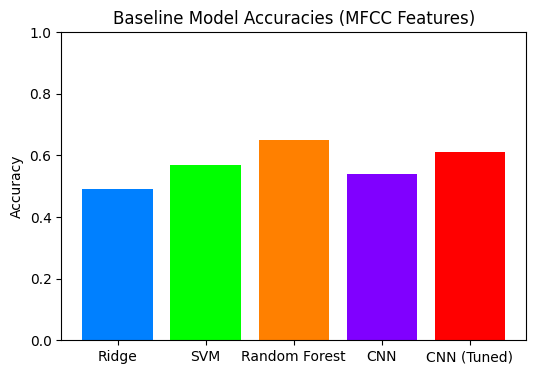

In [36]:
# Table

print("\nModel Accuracy Comparison")
print("----------------------------")
print(f"Ridge Regression: {ridge_acc:.4f}")
print(f"SVM (RBF):        {svm_acc:.4f}")
print(f"Random Forest:    {rf_acc:.4f}")
print(f"CNN (Spectrograms): {cnn_acc:.4f}")
print(f"CNN Tuned (Spectrograms): {cnn_tune_acc:.4f}")

# Chart

import matplotlib.pyplot as plt

models = ["Ridge", "SVM", "Random Forest", "CNN", "CNN (Tuned)"]
accuracies = [ridge_acc, svm_acc, rf_acc, cnn_acc, cnn_tune_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=["#0080ff", "#00ff00", "#ff8000", "#8000ff","#ff0000"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracies (MFCC Features)")
plt.show()

# Confusion Matrices

import seaborn as sns
from sklearn.metrics import confusion_matrix

genre_names = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,5))
    sns.heatmap(
        cm,
        xticklabels=genre_names,
        yticklabels=genre_names,
        cmap="Blues",
        annot=False
    )
    plt.title(title)
    plt.xlabel("Predicted Genre")
    plt.ylabel("Actual Genre")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()



Random Forest achieves the highest accuracy (0.65), making it the strongest overall model in this comparison.

Tuned CNN (0.61) shows a clear jump in performance over the untuned CNN (0.54), demonstrating the impact of hyperparameter tuning.

SVM with RBF kernel (0.57) outperforms the linear Ridge Regression baseline, indicating that the MFCC feature space is not linearly separable.

Ridge Regression (0.49) performs worst, as expected for a linear model applied to complex audio features.

Overall, the chart shows that both ensemble methods and tuned deep learning models outperform simpler linear approaches, while outlining that tuning plays a critical role in CNN performance.

# Confusion Matrices

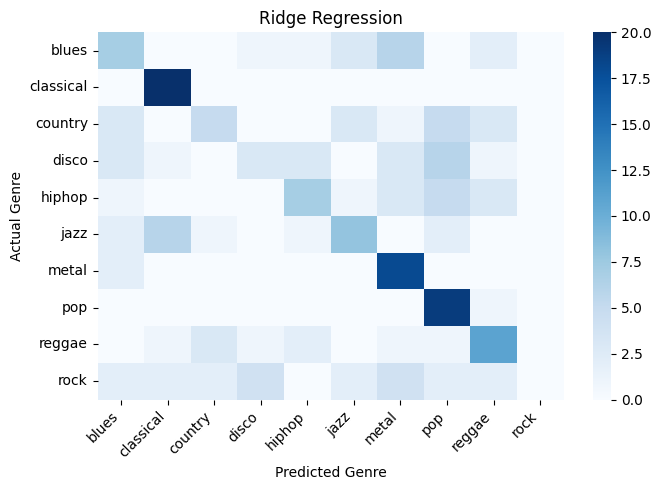

In [28]:
plot_cm(y_test, ridge_pred, "Ridge Regression")

Ridge Regression (MFCCs)

Weak diagonal

Strong confusion between similar genres

Serves as a baseline to demonstrate the limits of the linear model

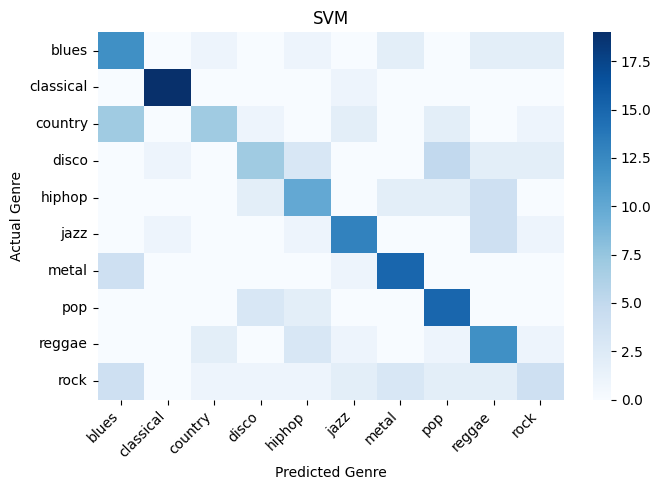

In [29]:
plot_cm(y_test, svm_pred, "SVM")

Stronger diagonal than Ridge Regression

Reduced confusion for several genres

Still struggling with similar genres

Confirms benefit of non-linear decision boundaries on MFCCs

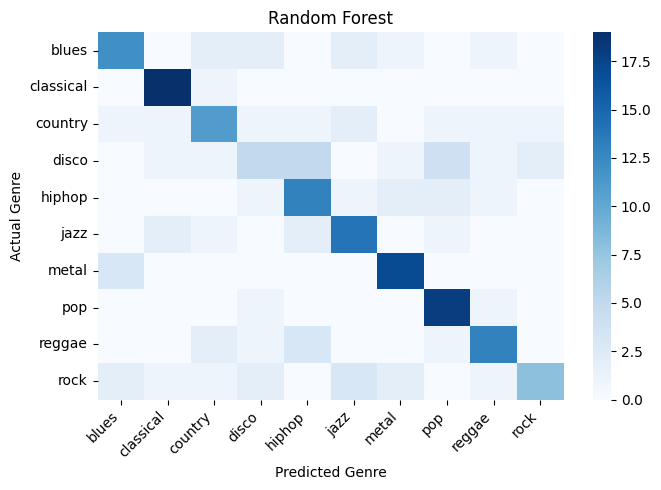

In [30]:
plot_cm(y_test, rf_pred, "Random Forest")

Cleanest diagonal compared to the other classical models

Fewer errors, less confusion in general of course

Handles feature interactions better than SVM

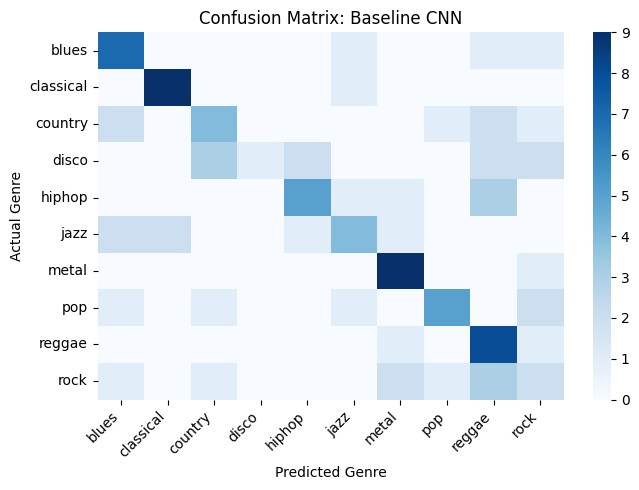

In [31]:
plot_cm(y_true, baseline_pred, "Confusion Matrix: Baseline CNN")

Baseline CNN (Spectrograms)

Diagonal present but inconsistent

Some genres well-recognized, others frequently confused

Errors often spread across multiple classes

Indicates CNN can learn time–frequency patterns but needs tuning

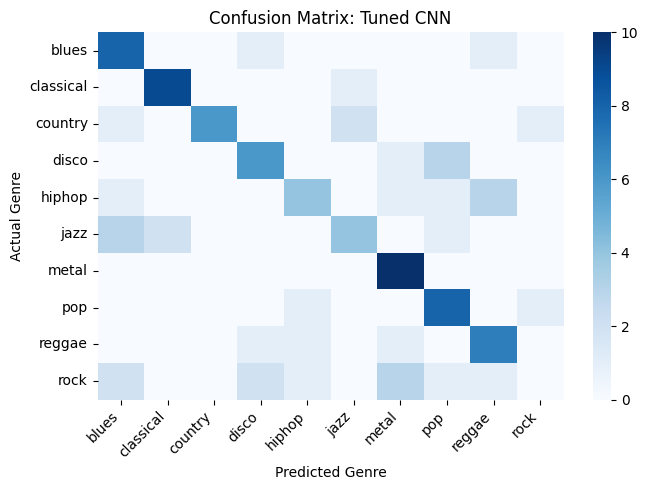

In [32]:
plot_cm(y_true, tuned_pred, "Confusion Matrix: Tuned CNN")

Tuned CNN (Spectrograms)

Noticeably stronger diagonal than baseline CNN

Fewer random inconsistencies

Improved class separation for many genres

Confirms tuning actually also improved generalization, not just accuracy

# A Small Disclaimer on the GTZAN Dataset

Towards the end of development, were curious about our results and saw some comments in our original resource that raised questions about the dataset itself. We found that it had several inconsistencies.

Due to known labeling errors and duplicated samples in the GTZAN dataset, results are reported for comparative analysis between models rather than as definitive genre classification accuracy. This might contribute to the overall low yield in accuracy across every approach we implemented.
Resources on this: https://arxiv.org/abs/1306.1461 and https://vbn.aau.dk/ws/portalfiles/portal/74499095/GTZANDB.pdf